# Análisis Bioestadístico: Evolución de la Morfología Craneal en el Egipto Predinástico | Statistical Analysis: Evolution of Cranial Morphology in Predynastic Egypt

## Descripción del Proyecto | Project Overview 

Este estudio aplica técnicas de Inferencia Estadística y Minería de Datos para evaluar cambios morfológicos en restos arqueológicos de Egipto. El objetivo central es determinar si existe una diferencia significativa en la anchura de los cráneos ($mm$) entre los periodos predinástico temprano y tardío.

A través de Python, este análisis valida hipótesis sobre la evolución de las estructuras óseas a medida que pasa el tiempo, utilizando un enfoque de rigor científico aplicable a entornos de investigación y desarrollo .

## Metodología | Methodology

### Análisis Descriptivo: Cálculo de medidas de tendencia central, dispersión, asimetría y curtosis de Fisher

In [1]:
# Importar todas las librerias que se van a usar.
import os 
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
# Esta libreria searborn sirve para hacer visualizaciones avanzadas
import seaborn as sns
import warnings
import math as mt
# Para hacer inferencias y otras cosas estadísticas se uso el scipy.stats
from scipy.stats import pearsonr

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

In [2]:
# Importo el conjunto de datos que es un archivo de Excel.
df = pd.read_excel('egyptian_cranium_biometric_data.xlsx')
df.head(5)

,Época histórica,Anchura del cráneo
0,1,133
1,1,131
2,1,131
3,1,132
4,1,134


In [3]:
# Muestra de predinástico temprano (1)
df_1 = df[df['Época histórica'] == 1] 
df_1.head(5)

,Época histórica,Anchura del cráneo
0,1,133
1,1,131
2,1,131
3,1,132
4,1,134


In [4]:
# Muestra de predinástico tardío (2)
df_2 = df[df['Época histórica'] == 2] 
df_2.head(5)

,Época histórica,Anchura del cráneo
30,2,132
31,2,133
32,2,131
33,2,133
34,2,133


#### Realizó un análisis descriptivo inicial de mi variable anchura para el periodo  predinástico temprano

In [5]:
valores_1 = pd.DataFrame(df_1['Anchura del cráneo'].describe())
valores_1.reset_index(inplace = True)
valores_1.rename(columns = {'index': 'Medida'}, inplace = True)
valores_1

,Medida,Anchura del cráneo
0,count,30.000000
1,mean,131.533333
2,std,0.819307
3,min,130.000000
4,25%,131.000000
5,50%,131.500000
6,75%,132.000000
7,max,134.000000


In [6]:
# Calcular la moda para el grupo 1 (predinástico temprano)
moda  = df_1['Anchura del cráneo'].mode()[0]
print(moda)
# Para este caso tengo un dataset bimodal porque tengo dos modas

131


In [7]:
# Cálculo del rango (valor max - Valor min)
rango = df_1['Anchura del cráneo'].max() - df_1['Anchura del cráneo'].min()
print(rango)

4


In [8]:
# Cálculo de la varianza
varianza = df_1['Anchura del cráneo'].var()
print(varianza)

0.6712643678160921


In [9]:
# Calculo del coeficiente de variacion de pearson porque me va a decir como de dispersos estan los datos 
# Tipicamente si tenemos un valor de coef de pearson mayor al 30% la media no es un buen descriptor
# std / mean
coef_var_P = valores_1.loc[2][1] /valores_1.loc[1][1] 
coef_var_P

np.float64(0.006228894440395486)

In [10]:
# Generacion de columnas de apoyo para el calculo de asimetria y curtosis 
df_1['Xi - Media'] = df_1['Anchura del cráneo'] - valores_1.loc[1][1]
# Para la asimetria
df_1['(Xi - Media)*3'] = df_1['Xi - Media']**3   
# Para la curtosis
df_1['(Xi - Media)*4'] = df_1['Xi - Media']**4

In [11]:
# tabla de los craneos del periodo temprano // con columnas de apoyo para el calculo de la forma de la distribucion
df_1.head(5)

,Época histórica,Anchura del cráneo,Xi - Media,(Xi - Media)*3,(Xi - Media)*4
0,1,133,1.466667,3.154963,4.627279
1,1,131,-0.533333,-0.151704,0.080909
2,1,131,-0.533333,-0.151704,0.080909
3,1,132,0.466667,0.101630,0.047427
4,1,134,2.466667,15.008296,37.020464


In [12]:
Coef_Fisher = df_1['(Xi - Media)*3'].sum()/((df_1['Época histórica'].count()-1)*mt.pow(valores_1.loc[2][1],3))
Coef_Fisher
# al tener un coeficiente de fisher positivo, Coef > 0, la asimetria es positiva que la cola a la derecha 
# de la media es más larga que la de la izquierda. 

np.float64(0.6459405126888941)

Asimetria de 0.646 al ser positiva, confirma que la cola de la distribución se extiende hacia la derecha.

In [13]:
# Coeficiente de curtosis de Fisher 
coeficiente_Curtosis = df_1['(Xi - Media)*4'].sum()/((df_1['Época histórica'].count()-1)*mt.pow(valores_1.loc[2][1],4)) -3
coeficiente_Curtosis

np.float64(1.1608932257459212)

Al ser mayor a cero (exceso de curtosis), indica una distribución leptocúrtica, es decir, más apuntada que la normal.

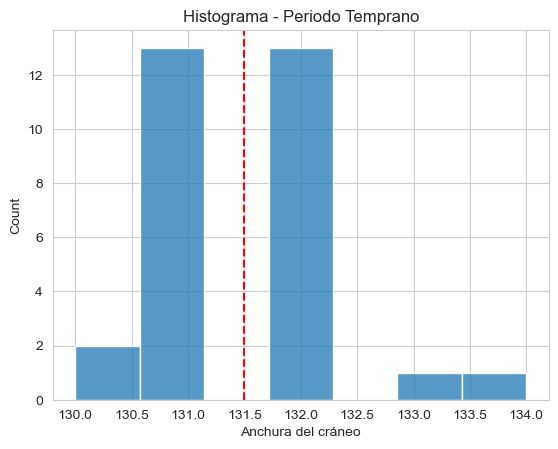

In [14]:
sns.histplot(data=df_1['Anchura del cráneo'] )
plt.axvline(x=valores_1.loc[5][1], color='red', linestyle='--')   #mediana
plt.title('Histograma - Periodo Temprano')
plt.savefig('histograma_craneos_ptemprano_AS.png', dpi=300, bbox_inches='tight')
plt.show() 

Se puede observar que es bimodal, en este caso elegi el primer valor que es 131.0

In [15]:
Medida = ['moda','rango','varianza','CoeficientePerson','CoeficienteFisher','CoeficienteCurtosis']
Anchura_del_Craneo = [moda, rango, varianza,coef_var_P, Coef_Fisher, coeficiente_Curtosis]

medidas_2 = pd.DataFrame({'Medida':Medida,'Anchura del cráneo':Anchura_del_Craneo})
medidas_2

,Medida,Anchura del cráneo
0,moda,131.000000
1,rango,4.000000
2,varianza,0.671264
3,CoeficientePerson,0.006229
4,CoeficienteFisher,0.645941
5,CoeficienteCurtosis,1.160893


In [16]:
#uniremos los dos dataframe con las medidas correspondientes para mostrarlo en uno solo
#con  esto la siguiente tabla muestra la totalidad de elementos correspondientes a medidas de tendencia central, no central, 
#forma , variabilidad
valores_w = pd.concat([valores_1, medidas_2], ignore_index=True)
valores_w
valores_w.to_clipboard()

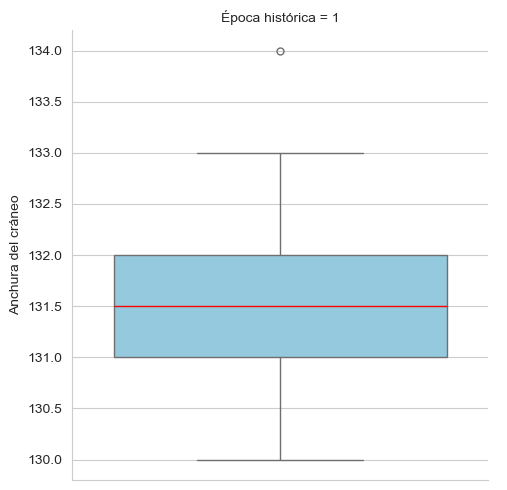

In [17]:
sns.catplot(data = df_1 ,  y='Anchura del cráneo' , col ='Época histórica' , kind = 'box', color='skyblue',medianprops={'color':'red'} )
plt.savefig('boxplot_craneos_ptemprano_AS.png', dpi=300, bbox_inches='tight')
plt.show()

Se observa un valor "outlier", cerca de 134.0 que se encuentra por encima del bigote superior de la caja.

#### Realizó un análisis descriptivo inicial de mi variable anchura para el periodo  predinástico tardio 

In [18]:
valores_2 = pd.DataFrame(df_2['Anchura del cráneo'].describe())
valores_2.reset_index(inplace = True)
valores_2.rename(columns = {'index': 'Medida'}, inplace = True)
valores_2

,Medida,Anchura del cráneo
0,count,30.000000
1,mean,132.466667
2,std,1.008014
3,min,131.000000
4,25%,132.000000
5,50%,133.000000
6,75%,133.000000
7,max,135.000000


In [19]:
# Calcular la moda para el grupo 2 (predinástico tardio)
moda_2  = df_2['Anchura del cráneo'].mode()[0]
moda_2
# tengo un solo valor de la moda

np.int64(133)

In [20]:
# Cálculo del rango (valor max - Valor min) (predinástico tardio)
rango_2 = df_2['Anchura del cráneo'].max() - df_2['Anchura del cráneo'].min()
rango_2

4

In [21]:
# Cálculo de la varianza (predinástico tardio)
varianza_2 = df_2['Anchura del cráneo'].var()
varianza_2

1.0160919540229887

In [22]:
# Calculo del coeficiente de variacion de pearson 
# Me va a decir como de dispersos estan los datos 
# Tipicamente si tenemos un valor de coef de pearson mayor al 30% la media no es un buen descriptor
# std / mean
coef_var_P_2 = valores_2.loc[2][1] /valores_2.loc[1][1]
coef_var_P_2

np.float64(0.007609566175043748)

In [23]:
# Generacion de columnas de apoyo para el calculo de asimetria y curtosis 
df_2['Xi - Media'] = df_2['Anchura del cráneo'] - valores_2.loc[1][1]
# Para la asimetria
df_2['(Xi - Media)*3'] = df_2['Xi - Media']**3   
# Para la curtosis
df_2['(Xi - Media)*4'] = df_2['Xi - Media']**4
df_2.head(5)

,Época histórica,Anchura del cráneo,Xi - Media,(Xi - Media)*3,(Xi - Media)*4
30,2,132,-0.466667,-0.101630,0.047427
31,2,133,0.533333,0.151704,0.080909
32,2,131,-1.466667,-3.154963,4.627279
33,2,133,0.533333,0.151704,0.080909
34,2,133,0.533333,0.151704,0.080909


In [24]:
Coef_Fisher_2 = df_2['(Xi - Media)*3'].sum()/((df_2['Época histórica'].count()-1)*mt.pow(valores_2.loc[2][1],3))
Coef_Fisher_2

np.float64(0.1918262295493577)

Al tener un coeficiente de fisher positivo 0.19 > 0, la asimetria es positiva que la cola a la derecha 
de la media es más larga que la de la izquierda. 

In [25]:
# Coeficiente de curtosis de Fisher 
coeficiente_Curtosis_2 = df_2['(Xi - Media)*4'].sum()/((df_2['Época histórica'].count()-1)*mt.pow(valores_2.loc[2][1],4)) -3
coeficiente_Curtosis_2

np.float64(-0.2800290739337874)

El exceso de curtosis menor a cero indica que una distribución de datos es platicúrtica, es decir, más aplanada y con colas más delgadas que una distribución normal.

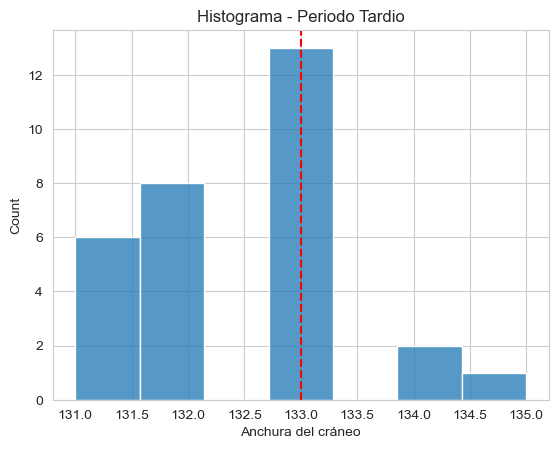

In [26]:
sns.histplot(data = df_2['Anchura del cráneo'] )
plt.axvline(x = valores_2.loc[5][1], color = 'red', linestyle = '--') #mediana
plt.title('Histograma - Periodo Tardio')
plt.savefig('histograma_craneos_ptardio_AS.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
Medida_2 = ['moda','rango','varianza','CoeficientePerson','CoeficienteFisher','CoeficienteCurtosis']
Anchura_del_Craneo_2 = [moda_2, rango_2, varianza_2, coef_var_P_2, Coef_Fisher_2, coeficiente_Curtosis_2]

medidas_2_2 = pd.DataFrame({'Medida': Medida_2,'Anchura del cráneo': Anchura_del_Craneo_2})
medidas_2_2

,Medida,Anchura del cráneo
0,moda,133.000000
1,rango,4.000000
2,varianza,1.016092
3,CoeficientePerson,0.007610
4,CoeficienteFisher,0.191826
5,CoeficienteCurtosis,-0.280029


In [28]:
#uniremos los dos dataframe con las medidas correspondientes para mostrarlo en uno solo
#con  esto la siguiente tabla muestra la totalidad de elementos correspondientes a medidas de tendencia central, no central, 
#forma , variabilidad
valores_w_2 = pd.concat([valores_2, medidas_2_2], ignore_index=True)
valores_w_2
valores_w_2.to_clipboard()

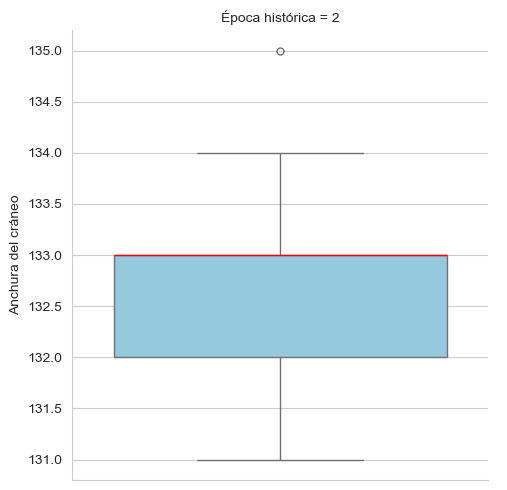

In [29]:
sns.catplot(data = df_2 ,  y = 'Anchura del cráneo' , col ='Época histórica' , kind = 'box', color='skyblue', medianprops={'color':'red'} )
plt.savefig('boxplot_craneos_ptardio_AS.png', dpi=300, bbox_inches='tight')
plt.show()

El diagrama de caja y bigotes nos enseña un valor atípico de 135.0, además que el valor de la mediana coincide con el valor de la moda en 133.0 indicándonos que el 75% de los datos se encuentran entre 131.0 y 133.0 confirmando que tenemos una asimetría positiva porque la mayoría de los valores se encuentran en el lado izquierdo.

#### COMPARATIVA DE LOS DIAGRAMAS DE CAJA PARA AMBOS PERIODOS

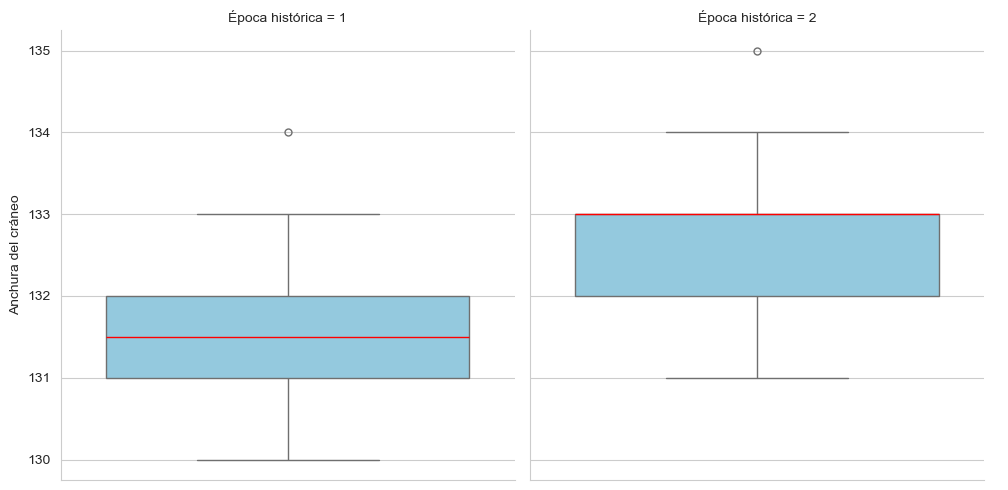

In [30]:
sns.catplot(data = df ,  y = 'Anchura del cráneo' , col ='Época histórica' , kind = 'box', color='skyblue',medianprops={'color':'red'} )
plt.savefig('boxplots_juntos_craneos_AS.png', dpi=300, bbox_inches='tight')
plt.show()

### Pruebas de Normalidad: Aplicación de los tests de Kolmogorov-Smirnov y Shapiro-Wilk para validar la distribución de las submuestras.

Para validar la distribución de las muestras, se plantearon las siguientes hipótesis en base a los tests de Kolmogorov-Smirnov y Shapiro-Wilk

Hipótesis 
$$H_0: \text{La distribución de la muestra sigue una distribución normal}$$
$$H_1: \text{La distribución de la muestra NO sigue una distribución normal}$$

Hypothesis
$$H_0: \text{The sample follows a normal distribution}$$
$$H_1: \text{The sample does NOT follow a normal distribution}$$

In [31]:
from scipy import stats
import numpy as np
from sklearn.preprocessing import StandardScaler

# conversion de los df filtrado a np.array para aprovechar sus caracteristicas
submuestra1 = np.array(df_1['Anchura del cráneo'])
submuestra2 = np.array(df_2['Anchura del cráneo'])

# Asegurarse de que las submuestras sean arreglos de una sola columna
submuestra1 = submuestra1.reshape(-1, 1)
submuestra2 = submuestra2.reshape(-1, 1)

# Inicializar standarscaler de scktlearn
scaler1 = StandardScaler()
scaler2 = StandardScaler()

# Normalizar las muestras
submuestra1 = scaler1.fit_transform(submuestra1)
submuestra2 = scaler2.fit_transform(submuestra2)

#llevar las submuestras a matriz unidmensional
submuestra1=submuestra1.flatten()
submuestra2=submuestra2.flatten()

# Aplicar la prueba de Kolmogorov-Smirnov
statistic1, pvalue1 = stats.kstest(submuestra1, 'norm')
statistic2, pvalue2 = stats.kstest(submuestra2, 'norm')

# Imprimir los resultados
print("RESULTADOS KOLMOGOROV - SMIRNOV:")
print("Resultados de la submuestra 1:")
print(f"Estadístico: {statistic1}, Valor p: {pvalue1}")
if pvalue1 > 0.05:
    print("La submuestra 1 sigue una distribución normal")
else:
    print("La submuestra 1 no sigue una distribución normal")

print("\nResultados de la submuestra 2:")
print(f"Estadístico: {statistic2}, Valor p: {pvalue2}")
if pvalue2 > 0.05:
    print("La submuestra 2 sigue una distribución normal")
else:
    print("La submuestra 2 no sigue una distribución normal")

# Aplicar la prueba de Kolmogorov-Smirnov
statistic1_SW, pvalue1_SW = stats.shapiro(submuestra1)
statistic2_SW, pvalue2_SW = stats.shapiro(submuestra2)

print('-------------------------------------------------------------------------------------------------------')
print("RESULTADOS SHAPIRO - WILK:")
print(f'Submuestra 1, p-valor: {pvalue1_SW}')
print('Sigue una distribución normal' if pvalue1_SW > 0.05 else 'NO sigue una distribución normal')

print(f'Submuestra 2, p-valor: {pvalue2_SW}')
print('Sigue una distribución normal' if pvalue2_SW > 0.05 else 'NO sigue una distribución normal')


RESULTADOS KOLMOGOROV - SMIRNOV:
Resultados de la submuestra 1:
Estadístico: 0.2460415331404474, Valor p: 0.04379464338101191
La submuestra 1 no sigue una distribución normal

Resultados de la submuestra 2:
Estadístico: 0.23809252465886277, Valor p: 0.055727049848177
La submuestra 2 sigue una distribución normal
-------------------------------------------------------------------------------------------------------
RESULTADOS SHAPIRO - WILK:
Submuestra 1, p-valor: 0.00034807826527245736
NO sigue una distribución normal
Submuestra 2, p-valor: 0.003341268408033742
NO sigue una distribución normal


Dado que el tamaño de la muestra es pequeño ($n=30$), el test de Shapiro-Wilk se considera más robusto y fiable que el de Kolmogorov-Smirnov . Por lo tanto, bajo un criterio riguroso, asumiremos que las muestras presentan desviaciones de la normalidad. 
Sin embargo, para fines académicos y siguiendo el requerimiento del estudio, se procederá con las pruebas paramétricas (Test $t$), discutiendo la validez de los resultados en la sección de inferencia .

El objetivo de esta fase es determinar si existen diferencias significativas en la anchura craneal entre ambos periodos históricos mediante el cálculo de intervalos de confianza al 90%, 95% y 99%. Dado que se trabaja con submuestras pequeñas ($n=30$) y varianzas poblacionales desconocidas, se ha seleccionado el uso de la prueba $t$ de Student para la inferencia de medias. Como requisito previo fundamental, se debe verificar el supuesto de homocedasticidad (igualdad de varianzas) a través de un test $F$ de Snedecor, asumiendo la independencia entre las muestras según las directrices del estudio.

#### Hipótesis de Igualdad de Varianzas | Homoscedasticity Hypotheses

**Hipótesis:**
$$H_0: \sigma_1^2 = \sigma_2^2 \quad \text{(Varianzas poblacionales iguales)}$$
$$H_1: \sigma_1^2 \neq \sigma_2^2 \quad \text{(Varianzas poblacionales diferentes)}$$

**Estadístico F observado:**
$$F = \frac{s_1^2}{s_2^2}$$

Para probar si las varianzas poblacionales son iguales o diferences, tomaremos un intervalor de confianza del 90%
Esta es una prueba de dos colas ya que estamos probando igualdad o diferencia.
Además, recordemos que en la prueba de kolmorov ya determinamos que la submuestra 1 no sigue una distribución normal, pero la submuestra 2 si sigue una distribución normal. 

Dado que las muestras tiene 30 valores , los grados de libertad para ambos son 29 .
Ademas alfa = 10% -- pero al ser una preuba de dos colas tomaremos alfa/2 para obtener los valores criticos de F. siendo 5%

In [32]:
# Esta parte construye mis intervalos de confianza 
# Encontrar los valores F de fisher 
from scipy.stats import f

gl1= valores_1.loc[0][1] - 1  #cantidad de elementos de la muestra1 - 1
gl2= valores_2.loc[0][1] - 1  #cantidad de elementos de  la muestra 2 -1
alfa_medios = 0.05

In [33]:
# valor critico por la derecha de la curva F
valor_tabla_f_derecha = f.ppf(1-alfa_medios,gl1,gl2)   

In [34]:
# al tener el mismo numero de GL la inversa es el valor de la izquierda
valor_tabla_f_izquierda = 1/valor_tabla_f_derecha    

In [35]:
print("La zona de aprobacion de la H0 con intervalo de confianza del 90% es:",valor_tabla_f_izquierda,"<F<",valor_tabla_f_derecha)

La zona de aprobacion de la H0 con intervalo de confianza del 90% es: 0.5373999648406917 <F< 1.8608114354760754


In [36]:
#calcularemos el estadistico de F que es las divicion de las desviaciones estandar de las muestras al cuadrado
Fisher = mt.pow (valores_1.loc[2][1],2)/mt.pow(valores_2.loc[2][1],2)
Fisher

0.6606334841628961

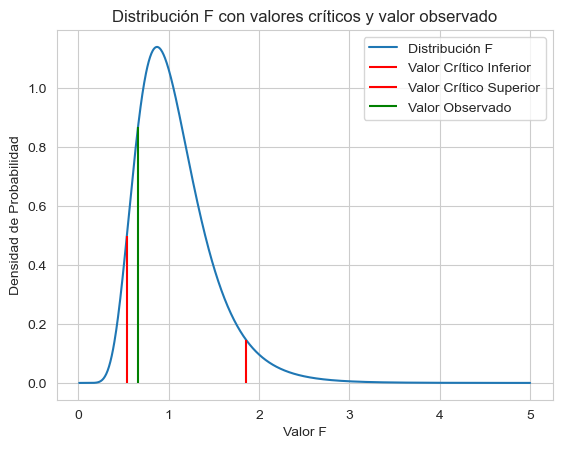

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f 

# Definir el rango de valores de F
f_values = np.linspace(0.01, 5, 1000)

# Calcular la distribución F
f_distribucion = f.pdf(f_values, gl1, gl2)

# Graficar la distribución F
plt.plot(f_values, f_distribucion, label='Distribución F')

# Graficar los valores críticos y el valor observado
plt.vlines(valor_tabla_f_izquierda, 0, f.pdf(valor_tabla_f_izquierda, gl1, gl2), colors='r', label='Valor Crítico Inferior')
plt.vlines(valor_tabla_f_derecha, 0, f.pdf(valor_tabla_f_derecha, gl1, gl2), colors='r', label='Valor Crítico Superior')
plt.vlines(Fisher, 0, f.pdf(Fisher, gl1, gl2), colors='g', label='Valor Observado')

# Configurar la leyenda y etiquetas
plt.legend()
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.title('Distribución F con valores críticos y valor observado')

# Mostrar la gráfica
plt.savefig('Valorescriticos_observado_AS.png', dpi=300, bbox_inches='tight')
plt.show()


El valor observado (verde) cae dentro de las líneas de los valores críticos (rojo), permitiéndonos concluir que a un 90% de confianza, no existe evidencia estadística suficiente para rechazar la hipótesis nula. Por lo tanto, aceptamos H0 que nos indica que las desviaciones estándar de ambas muestras son iguales. 

In [38]:
#Ahora sabiendo que las muestras son independientes -
# Las varianzas desconocidas y ademas estas son Iguales Podemos
#calcular de lleno el intervalor de confianza para la diferencua de Medias

In [39]:
from scipy.stats import t
# Nos dice qué tan lejos está un grupo del otro en el centro de la campana.
diferencia_medias = valores_1.loc[1][1] - valores_2.loc[1][1] 

n1 = valores_1.loc[0][1]
n2 = valores_2.loc[0][1]
s1 = valores_1.loc[2][1]
s2 = valores_2.loc[2][1]

#Representa el número de datos que "tienen libertad" de variar
grados_libertad = n1+n2-2

#Combina las desviaciones de ambos grupos para estimar cuánto error cometemos al decir que esa diferencia de medias es la "verdadera".
error_standar  = mt.sqrt((((n1*mt.pow(s1,2)+n2*mt.pow(s2,2))*((1/n1)+(1/n2)))/(grados_libertad)))

intervalo_90 = stats.t.interval(0.90, grados_libertad, loc = diferencia_medias, scale = error_standar)
intervalo_95 = stats.t.interval(0.95, grados_libertad, loc = diferencia_medias, scale = error_standar)
intervalo_99 = stats.t.interval(0.99, grados_libertad, loc = diferencia_medias, scale = error_standar)

In [40]:
print("los intervalos de confianza para la diferencia de medias con un 90% de confianza es:" ,intervalo_90)
print("-------------------------------------------------------------------------------------------------------")
print("los intervalos de confianza para la diferencia de medias con un 95% de confianza es:" ,intervalo_95)
print("-------------------------------------------------------------------------------------------------------")
print("los intervalos de confianza para la diferencia de medias con un 99% de confianza es:" ,intervalo_99)

los intervalos de confianza para la diferencia de medias con un 90% de confianza es: (np.float64(-1.3365370179152296), np.float64(-0.5301296487514446))
-------------------------------------------------------------------------------------------------------
los intervalos de confianza para la diferencia de medias con un 95% de confianza es: (np.float64(-1.416177718044257), np.float64(-0.45048894862241723))
-------------------------------------------------------------------------------------------------------
los intervalos de confianza para la diferencia de medias con un 99% de confianza es: (np.float64(-1.575758231239763), np.float64(-0.29090843542691114))


#### Para poder probar la diferencia de medias de dos poblaciones. debemos considerar que se deben cumplir 3 condiciones

1. Normalidad de los datos   (con la prueba de kolmogrov- smirnoy se probo que las muestras siguen una Distribucion Normal)
2. Homogenidad de la varianza           (se demostro en el ejericio anterior que las varianzas son homogeneas con prueba F)
3. Independencia de las observaciones  (el ejericio nos exige que esta condicion ya se cumple)

Por lo que se cumplen todas las condiciones necesarias para poder aplicar las pruebas de hipotesis para diferencia de medias

**Hipótesis:**
$$H_0: \mu_1 = \mu_2 \quad \text{(Las medias de anchura son iguales en ambos periodos)}$$
$$H_1: \mu_1 \neq \mu_2 \quad \text{(Existe una diferencia significativa entre periodos)}$$

**Estadístico de contraste (t-score):**
$$t = \frac{\bar{x}_1 - \bar{x}_2}{SE_{pooled}}$$

Como tenemos una prueba de hipotesis de comprobar si las medias son iguales o distintas, esta corresponde a una prueba de  dos colas. 

Ademas consideraremos un intervalo de confianza del 95% por lo que el alfa sera 0.025 -- a cada lado de la curva 

Tambien tenemos los grados de libertad correspindeintes a N1 +N2 -2 

In [41]:
# Calcularemos los valores cirticos correspondeintes a la distribucion T 
alfa = 0.05
alfa_medios = alfa/2

lim_sup = t.ppf(1-alfa_medios ,grados_libertad)
lim_inf = t.ppf(alfa_medios , grados_libertad)

print("La zona de aceptacion para la prueba es :" ,lim_inf , "," ,lim_sup)

La zona de aceptacion para la prueba es : -2.001717484145236 , 2.0017174841452356


Calculo del valor T

t = (Mmuestral1 - Mmuestral2) - (Mpobalcional1 - Mpoblacional2) / Error Standr Estimado

como sabemos estamos probando en la Ho que las MediasPoblacionales son iguales, asi que la diferencia de las Medias en la formula anterior es 0 --- (Mpobalcional1 - Mpoblacional2) = 0

quedandonos el T:

t = (Mmuestral1 - Mmuestral2) / Error Standr Estimado

teniendo estos valores ya listos, calcularemos el Tobservado

In [42]:
# Calculo del error estandar, este error es el mismo del ejericcio anterior 
t = float((diferencia_medias)/(error_standar))
print("el valor critico de T es :", t)

el valor critico de T es : -3.869299739267822


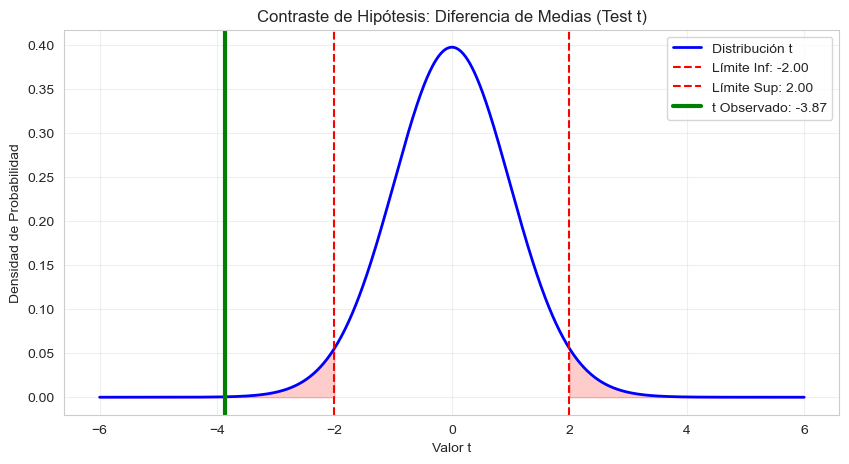

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# 1. Datos calculados (Asegúrate de que estas variables existan)
t_observado = -3.86929973 
grados_libertad = 58 
lim_inf = -2.001717484145236
lim_sup = 2.0017174841452356

# 2. Definir el rango de valores de t (Ampliado a -6 para ver el t_observado)
t_values = np.linspace(-6, 6, 1000)
t_distribucion = t.pdf(t_values, grados_libertad)

# 3. Crear el gráfico
plt.figure(figsize=(10, 5))
plt.plot(t_values, t_distribucion, label='Distribución t', color='blue', lw=2)

# 4. Graficar los valores críticos (Líneas rojas)
plt.axvline(lim_inf, color='r', linestyle='--', label=f'Límite Inf: {lim_inf:.2f}')
plt.axvline(lim_sup, color='r', linestyle='--', label=f'Límite Sup: {lim_sup:.2f}')

# 5. Graficar el VALOR OBSERVADO (Línea verde gruesa)
# Usamos axvline para que cruce todo el gráfico de arriba a abajo
plt.axvline(t_observado, color='g', linewidth=3, label=f't Observado: {t_observado:.2f}')

# 6. Sombrear la zona de rechazo para mejor visualización (Storytelling)
x_rechazo_inf = np.linspace(-6, lim_inf, 100)
plt.fill_between(x_rechazo_inf, t.pdf(x_rechazo_inf, grados_libertad), color='red', alpha=0.2)
x_rechazo_sup = np.linspace(lim_sup, 6, 100)
plt.fill_between(x_rechazo_sup, t.pdf(x_rechazo_sup, grados_libertad), color='red', alpha=0.2)

# 7. Configuración de etiquetas
plt.title('Contraste de Hipótesis: Diferencia de Medias (Test t)')
plt.xlabel('Valor t')
plt.ylabel('Densidad de Probabilidad')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Mostrar
plt.savefig('prueba_de_medias', dpi=300, bbox_inches='tight')
plt.show()